In [2]:
import json
import numpy as np

# 1) 파일 열기
file_path = "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.80.npz"
data = np.load(file_path, allow_pickle=True)

# 2) 들어있는 키 전부 확인
print("keys:", list(data.files))

# 3) 배열 꺼내기 — shape 로 크기 확인
tau_des    = data["tau_des"]      # (N, 12), pd loop 5 ms (pre-V_bus)
tau_cmd    = data["tau_cmd"]      # (N, 12), pd loop 5 ms (post-V_bus)
tau_actual = data["tau_actual"]   # (N, 12), physics 0.1 ms
I_des      = data["I_des"]        # (N, 12), pd loop 5 ms
q_des      = data["q_des"]        # (N, 12), policy 20 ms
print("tau_des shape    :", tau_des.shape)
print("tau_cmd shape    :", tau_cmd.shape)
print("tau_actual shape :", tau_actual.shape)
print("I_des shape      :", I_des.shape)
print("q_des shape      :", q_des.shape)

# 4) meta 는 JSON 문자열 → dict 로 변환
meta = json.loads(str(data["meta"]))
print("\n[meta] 주요 필드")
print("  num_steps    :", meta["num_steps"])
print("  dt (log)     :", meta["dt"], "s  (=", meta["fs"], "Hz)")
print("  cmd          :", meta["cmd"])
print("  demag_leg    :", meta["demag_leg"])
print("  demag_factor :", meta["demag_factor"])
print("  joint_names  :", meta["q_all_joint_names"])

keys: ['tau_cmd', 'tau_des', 'tau_actual', 'I_cmd', 'I_des', 'I_actual', 'q_all', 'qd_all', 'q_des', 'foot_contact', 'base_pos', 'base_quat', 'base_rpy', 'base_lin_vel', 'base_ang_vel', 'cmd_vel', 'meta']
tau_des shape    : (1000, 12)
tau_cmd shape    : (1000, 12)
tau_actual shape : (1000, 12)
I_des shape      : (1000, 12)
q_des shape      : (1000, 12)

[meta] 주요 필드
  num_steps    : 1000
  dt (log)     : 0.02 s  (= 50.0 Hz)
  cmd          : {'vx': 0.5, 'vy': 0.0, 'wz': 0.0}
  demag_leg    : RR
  demag_factor : 0.8
  joint_names  : ['FL_hip_joint', 'FR_hip_joint', 'RL_hip_joint', 'RR_hip_joint', 'FL_thigh_joint', 'FR_thigh_joint', 'RL_thigh_joint', 'RR_thigh_joint', 'FL_calf_joint', 'FR_calf_joint', 'RL_calf_joint', 'RR_calf_joint']


In [23]:
# ═══════════════════════════════════════════════════════════════════════
#  시간축 조절 (이 노트북 모든 plot / 통계 공통)
#
#  T_MAX_S 만 변경하면 자동으로:
#    1) np.load(*.npz) 가 모든 시계열을 first T_MAX_S 초로 자동 truncate
#    2) meta['num_steps'] 도 truncate 길이로 갱신 (t 축 자동 일치)
#    3) plot 셀 끝의 _apply_time_window() 가 추가로 xlim 적용
#
#  → scatter / RMS / regression / FFT 등 모두 잘린 데이터로 계산.
#    None 이면 원본 전체.
# ═══════════════════════════════════════════════════════════════════════
import json as _json
import numpy as np
import matplotlib.pyplot as plt

T_MAX_S = 30.0   # None / 5.0 / 10.0 ...


# ── np.load 모키 패치 — npz with meta 만 영향, 그 외 그대로 ───────
class _ClippedNpz:
    """npz wrapper: T_MAX_S 가 set 이면 시계열 첫 N 샘플로 잘라 반환."""
    def __init__(self, raw):
        self._raw = raw
        try:
            self._meta = _json.loads(str(raw['meta']))
            self._n_full = int(self._meta['num_steps'])
            self._dt = float(self._meta['dt'])
        except Exception:
            self._meta = None

    @property
    def files(self): return self._raw.files

    def __contains__(self, k): return k in self._raw.files

    def __iter__(self): return iter(self._raw.files)

    def close(self): self._raw.close()

    def __getitem__(self, k):
        v = self._raw[k]
        if T_MAX_S is None or self._meta is None:
            return v
        n_clip = min(self._n_full, int(round(T_MAX_S / self._dt)))
        if k == 'meta':
            # num_steps 갱신해서 반환 (str(meta) 후 json.loads 호환)
            meta_c = dict(self._meta); meta_c['num_steps'] = n_clip
            return np.array(_json.dumps(meta_c, ensure_ascii=False), dtype=object)
        if hasattr(v, 'shape') and v.ndim >= 1 and v.shape[0] == self._n_full:
            return v[:n_clip]
        return v


_orig_np_load = np.load._orig if hasattr(np.load, '_orig') else np.load


def _smart_load(path, *args, **kwargs):
    raw = _orig_np_load(path, *args, **kwargs)
    if (T_MAX_S is not None and hasattr(raw, 'files') and 'meta' in raw.files):
        return _ClippedNpz(raw)
    return raw


_smart_load._orig = _orig_np_load
np.load = _smart_load   # 모키 패치 (재실행 안전)


# ── plot 끝에 호출되는 xlim hook ────────────────────────────────
def _apply_time_window(fig=None):
    if T_MAX_S is None: return
    fig = fig or plt.gcf()
    time_kw = ('time', 't [', '[s]', '[ms]', 'sec', 'stride')
    for ax in fig.axes:
        xl = ax.get_xlabel().lower()
        if any(kw in xl for kw in time_kw):
            ax.set_xlim(left=0, right=T_MAX_S)


print(f'T_MAX_S = {T_MAX_S}  (np.load 자동 클립 + xlim hook 적용)')


T_MAX_S = 30.0  (np.load 자동 클립 + xlim hook 적용)


In [5]:
# joint 이름 → 열 번호
joint_names = meta["q_all_joint_names"]
col = joint_names.index("RR_calf_joint")
print(f"RR_calf_joint 은 {col} 번째 열")

# 그 열만 꺼내면 (N,) 1-D 시계열
tau_RR_calf_des    = tau_des[:, col]
tau_RR_calf_cmd    = tau_cmd[:, col]
tau_RR_calf_actual = tau_actual[:, col]
print("RR_calf tau_actual 첫 5 step:", tau_RR_calf_actual[:5])

RR_calf_joint 은 11 번째 열
RR_calf tau_actual 첫 5 step: [-2.3909414  8.79296   14.165065  16.541018  16.243948 ]


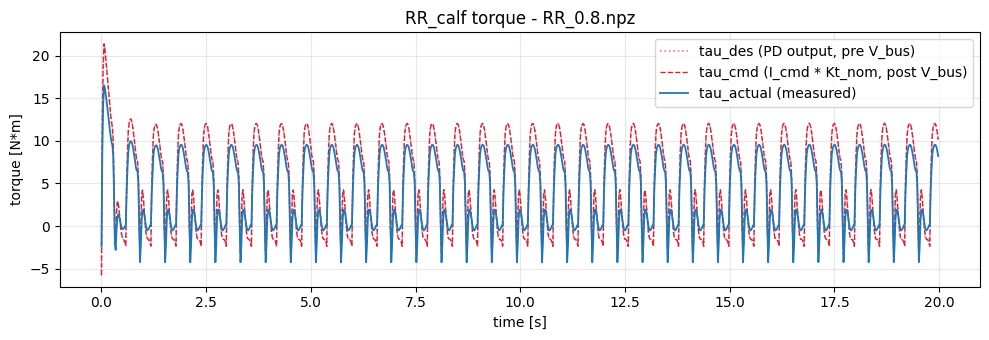

RR_calf V_bus saturation step fraction: 0.0% (max gap: 0.000 N*m)


<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt

# 시간축 만들기: 0, dt, 2·dt, ... (num_steps-1)·dt
t = np.arange(meta["num_steps"]) * meta["dt"]

plt.figure(figsize=(10, 3.5))
plt.plot(t, tau_RR_calf_des,    label="tau_des (PD output, pre V_bus)",       color="tab:pink", ls=":",  lw=1.2)
plt.plot(t, tau_RR_calf_cmd,    label="tau_cmd (I_cmd * Kt_nom, post V_bus)", color="tab:red",  ls="--", lw=1.0)
plt.plot(t, tau_RR_calf_actual, label="tau_actual (measured)",                color="tab:blue", ls="-",  lw=1.3)
plt.xlabel("time [s]")
plt.ylabel("torque [N*m]")
plt.title("RR_calf torque - RR_0.8.npz")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# V_bus 포화 빈도 진단: |tau_des - tau_cmd| > 1e-3 인 step 비율
gap = np.abs(tau_RR_calf_des - tau_RR_calf_cmd)
sat_frac = float(np.mean(gap > 1e-3))
print(f"RR_calf V_bus saturation step fraction: {sat_frac:.1%} "
      f"(max gap: {gap.max():.3f} N*m)")

_apply_time_window()


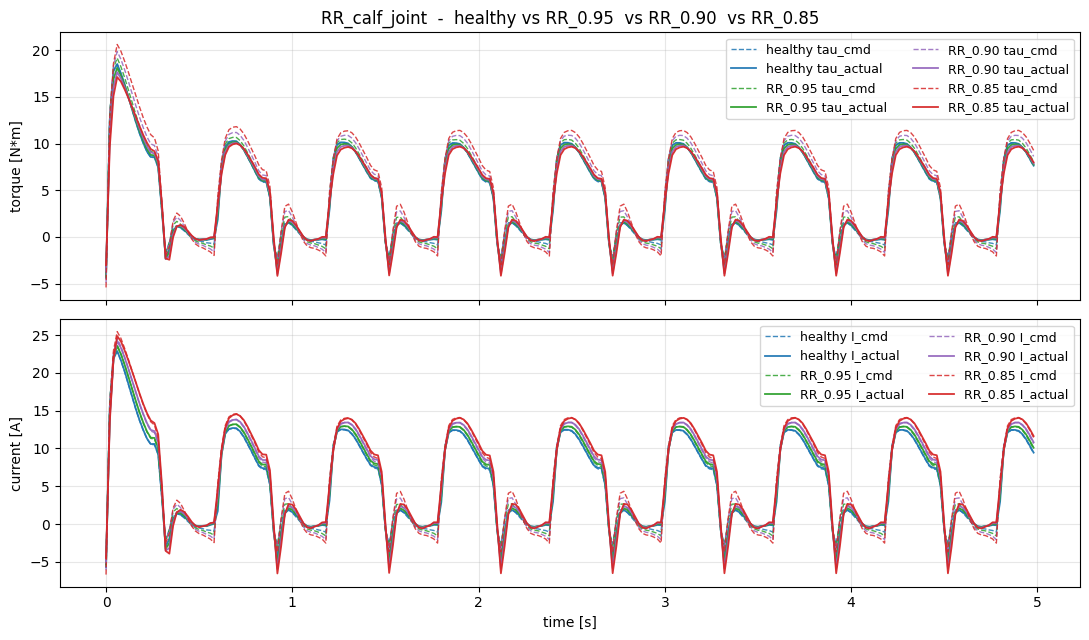


[RR_calf_joint] mean|·| over last 200 steps (steady-state)
  healthy   tau_cmd=  4.301  tau_actual=  4.242  I_cmd=  5.31  I_actual=  5.22
  RR_0.95   tau_cmd=  4.610  tau_actual=  4.261  I_cmd=  5.69  I_actual=  5.52
  measured ratio (tau_actual/tau_cmd in fault) = 0.924  (spec factor = 0.95)


<Figure size 640x480 with 0 Axes>

In [9]:
HEALTHY_FILE = "./aplus_tloop_hl_off/data/aplus_tloop_ki000/healthy.npz"
FAULT_FILE_095   = "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.95.npz"
FAULT_FILE_090   = "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.90.npz"
FAULT_FILE_085   = "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.85.npz"
JOINT        = "RR_calf_joint"

healthy = np.load(HEALTHY_FILE, allow_pickle=True)
FAULT_FILE_095   = np.load(FAULT_FILE_095,   allow_pickle=True)
FAULT_FILE_090   = np.load(FAULT_FILE_090,   allow_pickle=True)
FAULT_FILE_085   = np.load(FAULT_FILE_085,   allow_pickle=True)
h_meta  = json.loads(str(healthy["meta"]))
f_meta_095  = json.loads(str(FAULT_FILE_095["meta"]))
f_meta_090  = json.loads(str(FAULT_FILE_090["meta"]))
f_meta_085  = json.loads(str(FAULT_FILE_085["meta"]))

c_h = h_meta["q_all_joint_names"].index(JOINT)
c_f_095 = f_meta_095["q_all_joint_names"].index(JOINT)
c_f_090 = f_meta_090["q_all_joint_names"].index(JOINT)
c_f_085 = f_meta_085["q_all_joint_names"].index(JOINT)

t_h = np.arange(h_meta["num_steps"]) * h_meta["dt"]
t_f_095 = np.arange(f_meta_095["num_steps"]) * f_meta_095["dt"]
t_f_090 = np.arange(f_meta_090["num_steps"]) * f_meta_090["dt"]
t_f_085 = np.arange(f_meta_085["num_steps"]) * f_meta_085["dt"]

fault_tag_095 = f_meta_095.get("case_tag", f"{f_meta_095['demag_leg']}_{f_meta_095['demag_factor']}")
fault_tag_090 = f_meta_090.get("case_tag", f"{f_meta_090['demag_leg']}_{f_meta_090['demag_factor']}")
fault_tag_085 = f_meta_085.get("case_tag", f"{f_meta_085['demag_leg']}_{f_meta_085['demag_factor']}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

# ── torque: healthy(2) + fault(2) = 총 4 선 ──
ax = axes[0]
ax.plot(t_h, healthy["tau_cmd"][:, c_h],    color="tab:blue",    ls="--", lw=1.0, alpha=0.85, label="healthy tau_cmd")
ax.plot(t_h, healthy["tau_actual"][:, c_h], color="tab:blue",   ls="-",  lw=1.3, alpha=0.95, label="healthy tau_actual")
ax.plot(t_f_095, FAULT_FILE_095["tau_cmd"][:, c_f_095],      color="tab:green", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_095} tau_cmd")
ax.plot(t_f_095, FAULT_FILE_095["tau_actual"][:, c_f_095],   color="tab:green",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_095} tau_actual")
ax.plot(t_f_090, FAULT_FILE_090["tau_cmd"][:, c_f_090],      color="tab:purple", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_090} tau_cmd")
ax.plot(t_f_090, FAULT_FILE_090["tau_actual"][:, c_f_090],   color="tab:purple", ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_090} tau_actual")
ax.plot(t_f_085, FAULT_FILE_085["tau_cmd"][:, c_f_085],      color="tab:red", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_085} tau_cmd")
ax.plot(t_f_085, FAULT_FILE_085["tau_actual"][:, c_f_085],   color="tab:red",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_085} tau_actual")
ax.set_ylabel("torque [N*m]")
ax.set_title(f"{JOINT}  -  healthy vs {fault_tag_095}  vs {fault_tag_090}  vs {fault_tag_085}")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9, ncol=2)

# ── current: healthy(2) + fault(2) = 총 4 선 ──
ax = axes[1]
ax.plot(t_h, healthy["I_cmd"][:, c_h],    color="tab:blue",    ls="--", lw=1.0, alpha=0.85, label="healthy I_cmd")
ax.plot(t_h, healthy["I_actual"][:, c_h], color="tab:blue",   ls="-",  lw=1.3, alpha=0.95, label="healthy I_actual")
ax.plot(t_f_095, FAULT_FILE_095["I_cmd"][:, c_f_095],      color="tab:green", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_095} I_cmd")
ax.plot(t_f_095, FAULT_FILE_095["I_actual"][:, c_f_095],   color="tab:green",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_095} I_actual")
ax.plot(t_f_090, FAULT_FILE_090["I_cmd"][:, c_f_090],      color="tab:purple", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_090} I_cmd")
ax.plot(t_f_090, FAULT_FILE_090["I_actual"][:, c_f_090],   color="tab:purple", ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_090} I_actual")
ax.plot(t_f_085, FAULT_FILE_085["I_cmd"][:, c_f_085],      color="tab:red", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_085} I_cmd")
ax.plot(t_f_085, FAULT_FILE_085["I_actual"][:, c_f_085],   color="tab:red",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_085} I_actual")
ax.set_ylabel("current [A]")
ax.set_xlabel("time [s]")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9, ncol=2)

fig.tight_layout()
plt.show()

# 정상상태 (마지막 200 step) 평균치 요약
def mean_abs_end(arr, col, n=200):
    return float(np.mean(np.abs(arr[-n:, col])))

print(f"\n[{JOINT}] mean|·| over last 200 steps (steady-state)")
print(f"  healthy   tau_cmd={mean_abs_end(healthy['tau_cmd'], c_h):7.3f}  "
      f"tau_actual={mean_abs_end(healthy['tau_actual'], c_h):7.3f}  "
      f"I_cmd={mean_abs_end(healthy['I_cmd'], c_h):6.2f}  "
      f"I_actual={mean_abs_end(healthy['I_actual'], c_h):6.2f}")
print(f"  {fault_tag_095:<9} tau_cmd={mean_abs_end(FAULT_FILE_095['tau_cmd'], c_f_095):7.3f}  "
      f"tau_actual={mean_abs_end(FAULT_FILE_095['tau_actual'], c_f_095):7.3f}  "
      f"I_cmd={mean_abs_end(FAULT_FILE_095['I_cmd'], c_f_095):6.2f}  "
      f"I_actual={mean_abs_end(FAULT_FILE_095['I_actual'], c_f_095):6.2f}")
ratio = mean_abs_end(FAULT_FILE_095['tau_actual'], c_f_095) / max(mean_abs_end(FAULT_FILE_095['tau_cmd'], c_f_095), 1e-9)
print(f"  measured ratio (tau_actual/tau_cmd in fault) = {ratio:.3f}  (spec factor = {f_meta_095['demag_factor']:.2f})")

_apply_time_window()


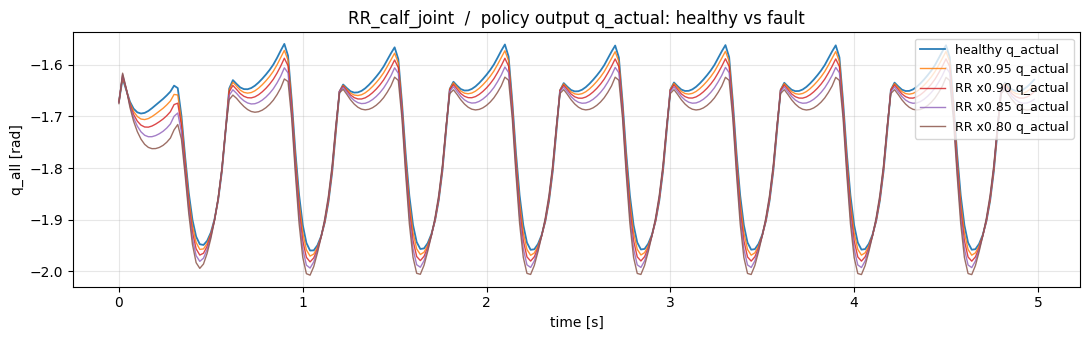


[RR_calf_joint] RMS(fault q_actual - healthy q_actual), steady-state
  RR x0.95    RMS=0.00870 rad  max|diff|=0.01482 rad
  RR x0.90    RMS=0.01849 rad  max|diff|=0.03022 rad
  RR x0.85    RMS=0.02934 rad  max|diff|=0.04723 rad
  RR x0.80    RMS=0.04164 rad  max|diff|=0.06808 rad


<Figure size 640x480 with 0 Axes>

In [10]:
# healthy 와 fault case 의 q_all 겹쳐보기
# (위 셀에서 쓴 파일·관절 변수를 그대로 재사용해도 되지만 self-contained 하게 다시 로드)
HEALTHY = "./aplus_tloop_hl_off/data/aplus_tloop_ki000/healthy.npz"
FAULTS  = [
    ("RR x0.95", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.95.npz", "tab:orange"),
    ("RR x0.90", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.90.npz", "tab:red"),
    ("RR x0.85", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.85.npz", "tab:purple"),
    ("RR x0.80", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.80.npz", "tab:brown"),
]
JOINT_NAME = "RR_calf_joint"

h  = np.load(HEALTHY, allow_pickle=True)
hm = json.loads(str(h["meta"]))
c  = hm["q_all_joint_names"].index(JOINT_NAME)
t  = np.arange(hm["num_steps"]) * hm["dt"]

plt.figure(figsize=(11, 3.5))

# healthy q_all 를 기준선으로
plt.plot(t, h["q_all"][:, c], color="tab:blue", lw=1.3, alpha=0.95,
         label="healthy q_actual")

# 각 fault case q_all 겹치기
for label, path, color in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    tf = np.arange(m["num_steps"]) * m["dt"]
    plt.plot(tf, d["q_all"][:, cf], color=color, lw=1.0, alpha=0.85,
             label=f"{label} q_actual")

plt.xlabel("time [s]")
plt.ylabel("q_all [rad]")
plt.title(f"{JOINT_NAME}  /  policy output q_actual: healthy vs fault")
plt.grid(alpha=0.3)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# 정량 차이: healthy 대비 RMS difference (정상상태)
TRANSIENT_S = 1.0
k0 = int(TRANSIENT_S / hm["dt"])
print(f"\n[{JOINT_NAME}] RMS(fault q_actual - healthy q_actual), steady-state")
for label, path, _ in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    diff = d["q_all"][k0:, cf] - h["q_all"][k0:, c]
    print(f"  {label:<10}  RMS={np.sqrt(np.mean(diff**2)):.5f} rad  "
          f"max|diff|={np.max(np.abs(diff)):.5f} rad")

_apply_time_window()


case              |roll|max  |pitch|max  |yaw drift|   z mean   z std
------------------------------------------------------------------------
healthy (x1.0)        1.80 deg     1.06 deg      -6.76 deg   0.308m  0.001m
RR x0.95              1.74 deg     1.02 deg      -6.53 deg   0.308m  0.001m
RR x0.90              1.67 deg     0.98 deg      -6.27 deg   0.307m  0.001m
RR x0.85              1.57 deg     0.97 deg      -6.02 deg   0.306m  0.002m


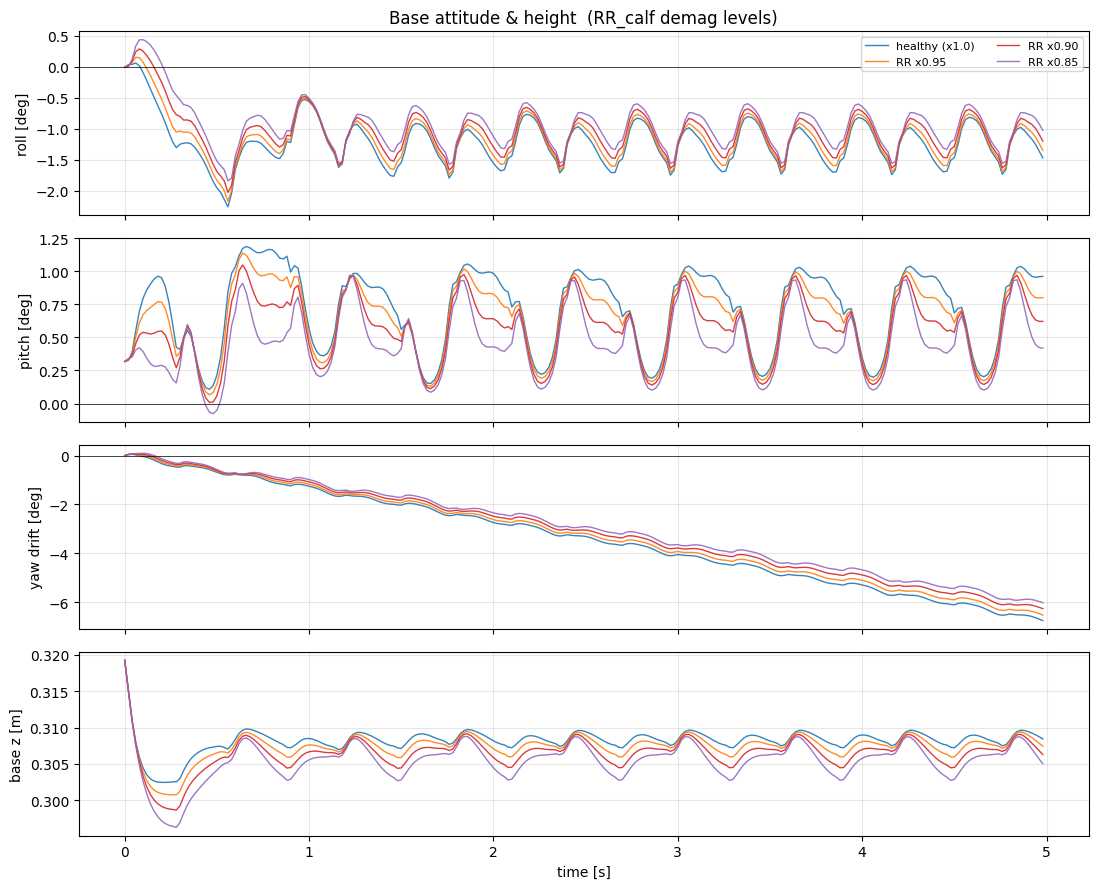

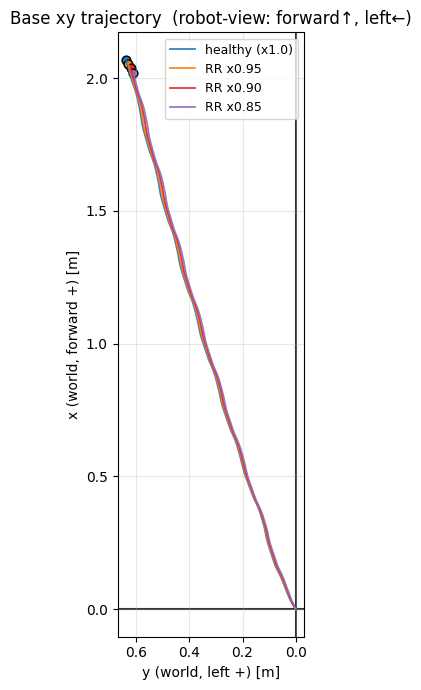

<Figure size 640x480 with 0 Axes>

In [11]:
TRANSIENT_S = 1.0

CASES_POSE = [
    ("healthy (x1.0)", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/healthy.npz", "tab:blue"),
    ("RR x0.95",        "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.95.npz",  "tab:orange"),
    ("RR x0.90",        "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.90.npz",  "tab:red"),
    ("RR x0.85",        "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.85.npz",  "tab:purple"),
]

# ── 4개 시계열 subplot: roll, pitch, yaw, z ──
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

print(f"{'case':<16} {'|roll|max':>10} {'|pitch|max':>11} {'|yaw drift|':>12} "
      f"{'z mean':>8} {'z std':>7}")
print("-" * 72)

for label, path, color in CASES_POSE:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    t = np.arange(m["num_steps"]) * m["dt"]

    rpy_deg = np.rad2deg(d["base_rpy"])
    roll, pitch, yaw = rpy_deg[:, 0], rpy_deg[:, 1], rpy_deg[:, 2]
    z = d["base_pos"][:, 2]

    axes[0].plot(t, roll,  color=color, lw=1.0, alpha=0.9, label=label)
    axes[1].plot(t, pitch, color=color, lw=1.0, alpha=0.9, label=label)
    # yaw 는 0 에서 시작하도록 offset (자세 drift 만 보려고)
    axes[2].plot(t, yaw - yaw[0], color=color, lw=1.0, alpha=0.9, label=label)
    axes[3].plot(t, z,     color=color, lw=1.0, alpha=0.9, label=label)

    # 통계
    k0 = int(TRANSIENT_S / m["dt"])
    print(f"{label:<16} {np.max(np.abs(roll[k0:])):>9.2f} deg  "
          f"{np.max(np.abs(pitch[k0:])):>7.2f} deg  "
          f"{(yaw[-1] - yaw[0]):>9.2f} deg  "
          f"{np.mean(z[k0:]):>6.3f}m  {np.std(z[k0:]):>5.3f}m")

axes[0].axhline(0, color="k", lw=0.5)
axes[1].axhline(0, color="k", lw=0.5)
axes[2].axhline(0, color="k", lw=0.5)

axes[0].set_ylabel("roll [deg]")
axes[1].set_ylabel("pitch [deg]")
axes[2].set_ylabel("yaw drift [deg]")
axes[3].set_ylabel("base z [m]")
axes[3].set_xlabel("time [s]")
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right", fontsize=8, ncol=2)
axes[0].set_title("Base attitude & height  (RR_calf demag levels)")
fig.tight_layout()
plt.show()

# ── xy trajectory (world frame, robot-view orientation) ──
fig, ax = plt.subplots(figsize=(5, 7))   # 세로로 긴 figure가 더 자연스러움
for label, path, color in CASES_POSE:
    d = np.load(path, allow_pickle=True)
    x = d["base_pos"][:, 0] - d["base_pos"][0, 0]   # forward (world +x)
    y = d["base_pos"][:, 1] - d["base_pos"][0, 1]   # left    (world +y)
    # 가로축 = y (왼쪽이 +y), 세로축 = x (위쪽이 +x)
    ax.plot(y, x, color=color, lw=1.3, alpha=0.9, label=label)
    ax.scatter(y[-1], x[-1], color=color, s=40, marker="o", edgecolor="k")

# 원점을 지나는 기준선 강조
ax.axhline(0, color="k", lw=1.5, alpha=0.8, zorder=0)   # world x = 0
ax.axvline(0, color="k", lw=1.5, alpha=0.8, zorder=0)   # world y = 0
ax.set_xlabel("y (world, left +) [m]")
ax.set_ylabel("x (world, forward +) [m]")
ax.invert_xaxis()                 # +y(왼쪽)이 화면 왼쪽으로 가도록 반전
ax.set_aspect("equal")
ax.set_title("Base xy trajectory  (robot-view: forward↑, left←)")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

_apply_time_window()


  healthy: 250 steps @ 20.0ms = 5.0s
  RR x0.95: 250 steps @ 20.0ms = 5.0s
  RR x0.90: 250 steps @ 20.0ms = 5.0s
  RR x0.85: 250 steps @ 20.0ms = 5.0s
  RR x0.80: 250 steps @ 20.0ms = 5.0s
  RR x0.75: 250 steps @ 20.0ms = 5.0s
  RR x0.70: 250 steps @ 20.0ms = 5.0s
=== Gait stats per demag factor (RR_calf, K_i=0, first 5s) ===
  duty factor = stance / (stance + swing) — trot 의 정상값 ~0.5


,label,stance_ms,swing_ms,period_ms,duty_factor,freq_Hz
factor,,,,,,
1.000000,healthy,324.85,261.94,586.78,0.55,1.70
0.950000,RR x0.95,324.85,261.94,586.78,0.55,1.70
0.900000,RR x0.90,326.67,260.65,587.31,0.56,1.70
0.850000,RR x0.85,326.67,260.65,587.31,0.56,1.70
0.800000,RR x0.80,323.03,265.16,588.19,0.55,1.70
0.750000,RR x0.75,327.27,260.65,587.92,0.56,1.70
0.700000,RR x0.70,327.27,260.65,587.92,0.56,1.70


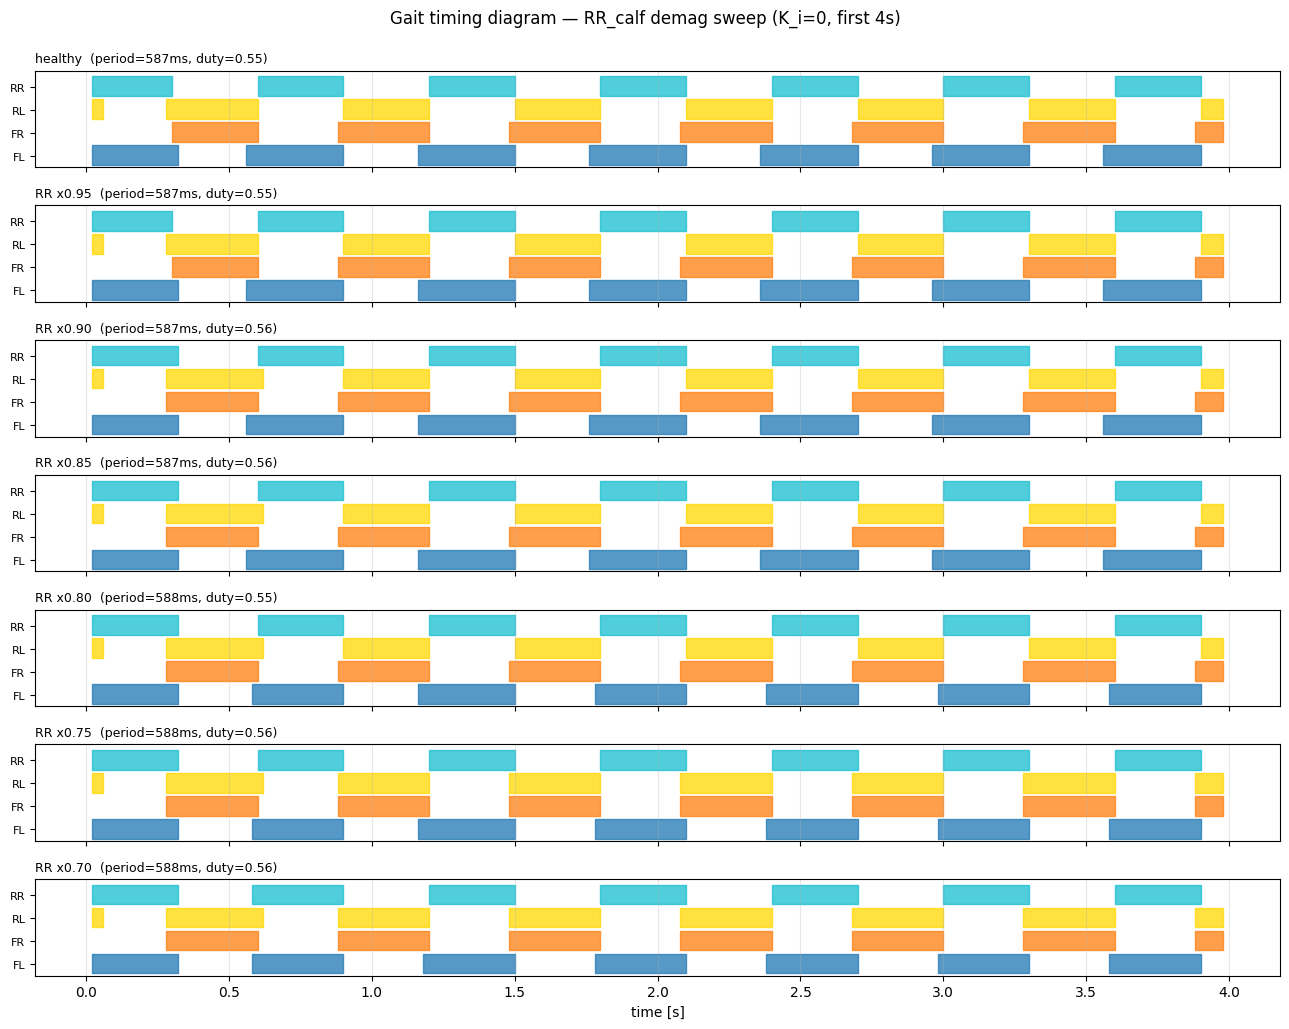

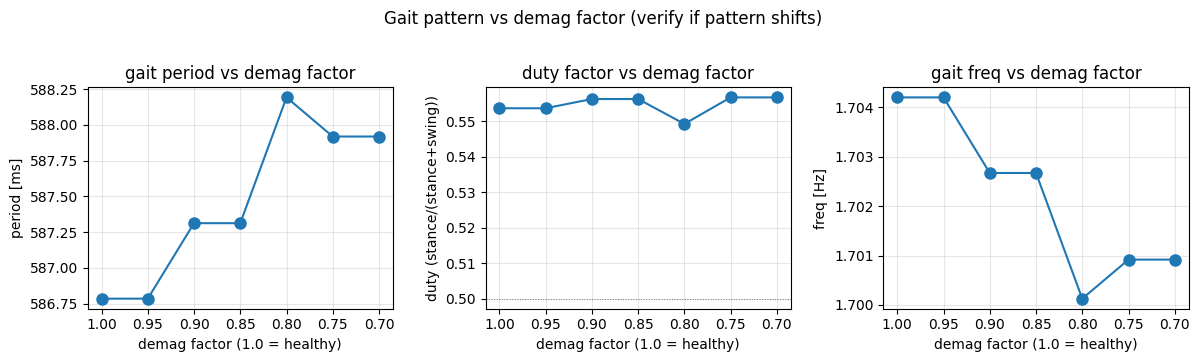

In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  보행 timing diagram (Gantt) + stance/swing/duty factor 통계
#  - K_i=0 고정. 대신 demag factor (fault level) 별 4 개 발 패턴을
#    가로 막대로. fault_data[factor] = {dt, n_steps, foot_contact, ...}.
#  - trot 이면 (FL+RR), (FR+RL) 대각 쌍이 동기화돼 교대로 디뎌짐.
#    같은 대각 쌍은 같은 계열 색 (파란/주황) 으로 묶어 시각화.
# ═══════════════════════════════════════════════════════════════════════
from pathlib import Path
import pandas as pd

GAIT_T_MAX_S = 4.0   # Gantt 그림에 보일 시간 [s] — T_MAX_S 이하면 자동 사용

# (factor, label, path) — healthy 부터 30 % demag 까지
GAIT_CASES = [
    (1.00, "healthy",  "./aplus_tloop_hl_off/data/aplus_tloop_ki000/healthy.npz"),
    (0.95, "RR x0.95", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.95.npz"),
    (0.90, "RR x0.90", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.90.npz"),
    (0.85, "RR x0.85", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.85.npz"),
    (0.80, "RR x0.80", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.80.npz"),
    (0.75, "RR x0.75", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.75.npz"),
    (0.70, "RR x0.70", "./aplus_tloop_hl_off/data/aplus_tloop_ki000/RR_0.70.npz"),
]

OUTPUT_DIR = Path('analysis_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)


def stance_swing_stats(contact, dt):
    """contact: [N] bool array. 한 발의 stance / swing 길이 통계."""
    contact = np.asarray(contact).astype(bool)
    diff = np.diff(contact.astype(int))
    rises = np.where(diff > 0)[0] + 1   # touchdown
    falls = np.where(diff < 0)[0] + 1   # liftoff
    stance, swing = [], []
    if len(rises) > 1 and len(falls) > 1:
        for r in rises:
            f = falls[falls > r]
            if len(f):
                stance.append((f[0] - r) * dt)
        for f in falls:
            r = rises[rises > f]
            if len(r):
                swing.append((r[0] - f) * dt)
    return np.array(stance), np.array(swing)


def gait_summary(fc, fc_names, dt):
    """4 개 발 평균 stance / swing / duty factor."""
    stance_all, swing_all = [], []
    per_foot = {}
    for k, name in enumerate(fc_names):
        s, w = stance_swing_stats(fc[:, k], dt)
        stance_all.extend(s.tolist()); swing_all.extend(w.tolist())
        per_foot[name] = (s.mean() if len(s) else float('nan'),
                          w.mean() if len(w) else float('nan'))
    stance_all = np.array(stance_all); swing_all = np.array(swing_all)
    if len(stance_all) > 0 and len(swing_all) > 0:
        duty = stance_all.mean() / (stance_all.mean() + swing_all.mean())
    else:
        duty = float('nan')
    return dict(stance_mean=stance_all.mean() if len(stance_all) else float('nan'),
                swing_mean=swing_all.mean() if len(swing_all) else float('nan'),
                duty=duty, per_foot=per_foot)


# ── 데이터 로드 → fault_data (T_MAX_S 자동 truncate) ────────
fault_data = {}
for factor, label, path in GAIT_CASES:
    try:
        d = np.load(path, allow_pickle=True)
    except FileNotFoundError:
        print(f'  {label}: MISSING (skip)')
        continue
    m = json.loads(str(d['meta']))
    fc = d['foot_contact']
    fault_data[factor] = {
        'label':        label,
        'dt':           float(m['dt']),
        'n_steps':      int(m['num_steps']),
        'foot_contact': np.asarray(fc),
        'foot_names':   m['foot_contact_names'],
    }
    print(f"  {label}: {m['num_steps']} steps @ {m['dt']*1000:.1f}ms = "
          f"{m['num_steps']*m['dt']:.1f}s")

duration_str = f'{T_MAX_S:.0f}s' if T_MAX_S is not None else 'full'


# ── Per-factor 통계 표 ──────────────────────────────────────
gait_rows = []
factors_sorted = sorted(fault_data.keys(), reverse=True)   # 1.00 → 0.70
for factor in factors_sorted:
    d = fault_data[factor]
    stats = gait_summary(d['foot_contact'], d['foot_names'], d['dt'])
    sm, wm = stats['stance_mean'], stats['swing_mean']
    period = (sm + wm) if not (np.isnan(sm) or np.isnan(wm)) else float('nan')
    freq   = (1.0 / period) if (not np.isnan(period) and period > 0) else float('nan')
    gait_rows.append(dict(
        factor=factor,
        label=d['label'],
        stance_ms=sm*1000 if not np.isnan(sm) else float('nan'),
        swing_ms =wm*1000 if not np.isnan(wm) else float('nan'),
        period_ms=period*1000 if not np.isnan(period) else float('nan'),
        duty_factor=stats['duty'],
        freq_Hz=freq,
    ))
gait_df = pd.DataFrame(gait_rows).set_index('factor')
print(f'=== Gait stats per demag factor (RR_calf, K_i=0, first {duration_str}) ===')
print('  duty factor = stance / (stance + swing) — trot 의 정상값 ~0.5')
_num_cols = ['stance_ms', 'swing_ms', 'period_ms', 'duty_factor', 'freq_Hz']
try:
    display(gait_df.style.format('{:.2f}', subset=_num_cols, na_rep='-'))
except (ValueError, TypeError):
    # 옛 pandas: na_rep / subset 미지원 → round + display
    display(gait_df.round(2))


# ── Per-factor Gantt 차트 ───────────────────────────────────
n_case = len(fault_data)
fig_g, axes_g = plt.subplots(n_case, 1, figsize=(13, 1.4*n_case + 0.5),
                              sharex=True)
if n_case == 1:
    axes_g = [axes_g]
# 대각 쌍 (FL+RR), (FR+RL) 동기 시각화 — 같은 쌍은 같은 계열 색.
foot_colors = {'FL': 'tab:blue',   'RR': 'tab:cyan',
               'FR': 'tab:orange', 'RL': 'gold'}

for ax, factor in zip(axes_g, factors_sorted):
    d = fault_data[factor]
    dt = d['dt']
    n_show = min(d['n_steps'], int(round(GAIT_T_MAX_S / dt)))
    t_arr = np.arange(n_show) * dt
    for k, name in enumerate(d['foot_names']):
        contact = d['foot_contact'][:n_show, k] > 0
        leg = next((kw for kw in foot_colors if kw in name), '')
        c = foot_colors.get(leg, 'gray')
        ax.fill_between(t_arr, k, k + 0.85, where=contact, step='post',
                        color=c, alpha=0.75)
    ax.set_yticks(np.arange(len(d['foot_names'])) + 0.4)
    ax.set_yticklabels([name.replace('_foot_collision', '') for name in d['foot_names']],
                        fontsize=8)
    ax.set_ylim(-0.1, len(d['foot_names']) + 0.1)
    period = gait_df.loc[factor, 'period_ms']
    duty   = gait_df.loc[factor, 'duty_factor']
    ax.set_title(f"{d['label']}  (period={period:.0f}ms, duty={duty:.2f})",
                  fontsize=9, loc='left')
    ax.grid(True, axis='x', alpha=0.3)

axes_g[-1].set_xlabel('time [s]')
fig_g.suptitle(f'Gait timing diagram — RR_calf demag sweep (K_i=0, first {GAIT_T_MAX_S:.0f}s)',
                y=0.995)
fig_g.tight_layout()
fig_g.savefig(OUTPUT_DIR / 'fig_gait_gantt_ki0_sweep.png',
               dpi=120, bbox_inches='tight')
plt.show()


# ── Duty factor + period vs factor 작은 그래프 ──────────────
fig_dp, axes_dp = plt.subplots(1, 3, figsize=(12, 3.5))
xs = factors_sorted   # 1.0 (healthy) → 0.70 (severe)
for ax, key, title, ylab in [
    (axes_dp[0], 'period_ms',   'gait period vs demag factor',  'period [ms]'),
    (axes_dp[1], 'duty_factor', 'duty factor vs demag factor',  'duty (stance/(stance+swing))'),
    (axes_dp[2], 'freq_Hz',     'gait freq vs demag factor',    'freq [Hz]')]:
    ys = [gait_df.loc[f, key] for f in xs]
    ax.plot(xs, ys, 'o-', color='tab:blue', lw=1.5, ms=8)
    ax.set_xlabel('demag factor (1.0 = healthy)')
    ax.set_ylabel(ylab); ax.set_title(title)
    ax.invert_xaxis()   # 1.0(healthy) → 0.7(severe) 가 왼→오른 진행
    ax.grid(alpha=0.3, which='both')
axes_dp[1].axhline(0.5, color='k', ls=':', lw=0.7, alpha=0.5)   # trot reference
fig_dp.suptitle('Gait pattern vs demag factor (verify if pattern shifts)', y=1.02)
fig_dp.tight_layout()
fig_dp.savefig(OUTPUT_DIR / 'fig_gait_metrics_ki0_sweep.png',
                dpi=120, bbox_inches='tight')
plt.show()


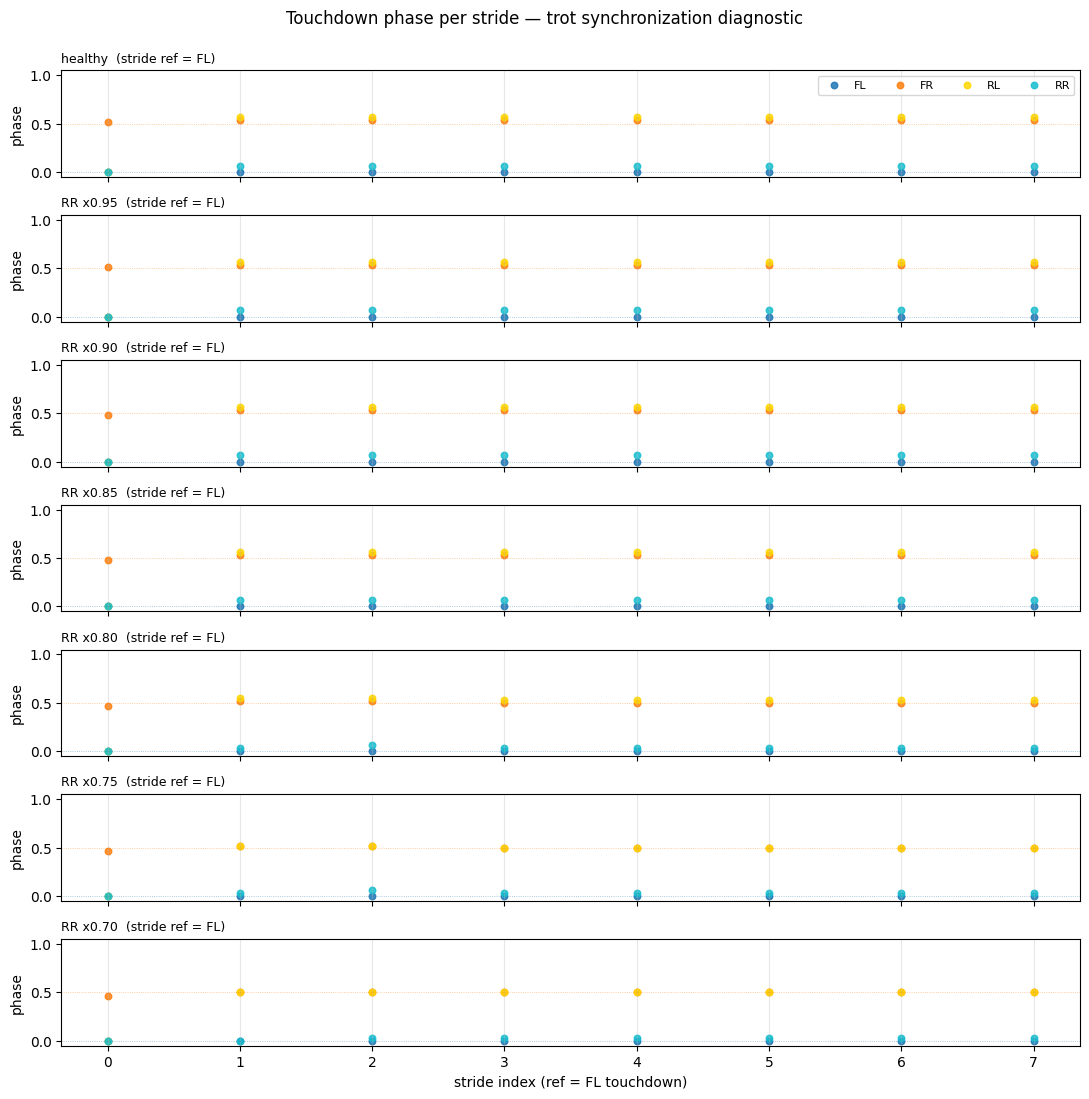

=== Touchdown phase MEAN per (factor × leg)  ref=FL ===
  정상 trot:  FL=RR≈0.0  ↔  FR=RL≈0.5


leg,FL,RR,FR,RL
factor,,,,
1.00,0.0,0.058,0.531,0.496
0.95,0.0,0.058,0.531,0.496
0.90,0.0,0.058,0.527,0.496
0.85,0.0,0.058,0.527,0.496
0.80,0.0,0.033,0.500,0.471
0.75,0.0,0.033,0.500,0.442
0.70,0.0,0.025,0.496,0.438


=== Touchdown phase STD (jitter)  per (factor × leg) ===
  값이 클수록 stride 마다 위상이 흔들림 → 동기화 깨짐


leg,FL,RR,FR,RL
factor,,,,
1.00,0.0,0.024,0.005,0.200
0.95,0.0,0.024,0.005,0.200
0.90,0.0,0.024,0.018,0.200
0.85,0.0,0.024,0.018,0.200
0.80,0.0,0.017,0.016,0.190
0.75,0.0,0.017,0.016,0.179
0.70,0.0,0.015,0.013,0.177


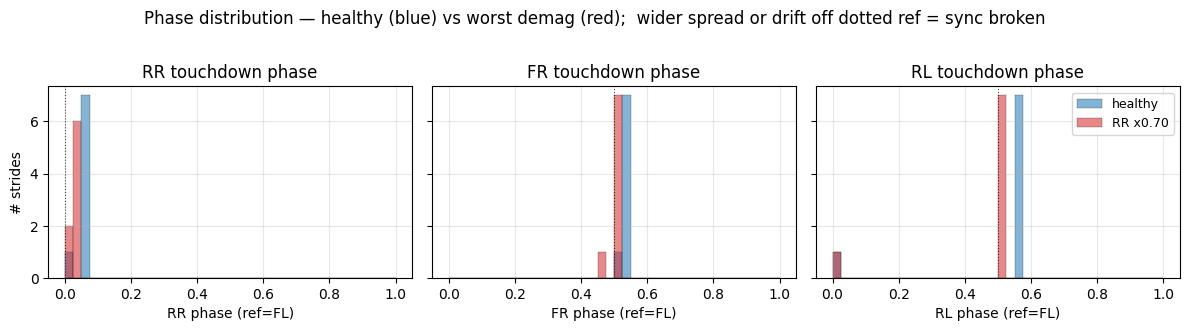

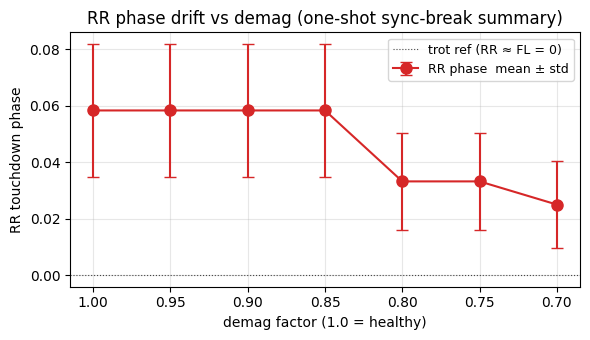

In [16]:
# ═══════════════════════════════════════════════════════════════════════
#  발 touchdown 위상차 분석 — RR_calf demag 가 trot 동기화를 깨는가
#  - FL touchdown 을 stride 기준 (phase=0). 같은 stride 안에서 다른 발
#    (FR/RL/RR) 의 touchdown phase ∈ [0,1) 을 stride 진행에 따라 시계열.
#  - 정상 trot: FL=0, RR≈0  (대각 쌍 동기)  ↔  FR=RL≈0.5  (반주기 차)
#  - demag 가 위상을 흔들면 RR phase 가 0 에서 벗어나거나 jitter (std) 가 ↑.
#  - 위 셀의 fault_data, factors_sorted, leg color 재사용.
# ═══════════════════════════════════════════════════════════════════════
PHASE_REF = 'FL'   # 기준 발 (stride 정의)


def touchdown_idx(contact):
    contact = np.asarray(contact).astype(bool).astype(int)
    return np.where(np.diff(contact) > 0)[0] + 1


def relative_phases(fc, fc_names, dt, ref=PHASE_REF):
    """각 stride (ref 발 touchdown ~ 다음 touchdown) 안에서 4 발의
    첫 touchdown phase ∈ [0, 1) 를 (stride, leg, phase) row 로."""
    ref_col = next((k for k, n in enumerate(fc_names) if ref in n), 0)
    ref_td = touchdown_idx(fc[:, ref_col])
    legs = []
    for k, name in enumerate(fc_names):
        leg = next((kw for kw in ('FL', 'FR', 'RL', 'RR') if kw in name), name)
        legs.append((leg, touchdown_idx(fc[:, k])))
    rows = []
    for ki in range(len(ref_td) - 1):
        t0, t1 = ref_td[ki], ref_td[ki + 1]
        T = (t1 - t0) * dt
        if T <= 0:
            continue
        for leg, td in legs:
            in_stride = td[(td >= t0) & (td < t1)]
            if len(in_stride) == 0:   # 해당 stride 안에 touchdown 없음 (drag 등)
                continue
            phase = (in_stride[0] - t0) * dt / T
            rows.append(dict(stride=ki, leg=leg, phase=phase))
    return pd.DataFrame(rows)


# ── Per-factor phase scatter (subplot grid) ─────────────────
n_case = len(fault_data)
fig_p, axes_p = plt.subplots(n_case, 1, figsize=(11, 1.5*n_case + 0.5),
                              sharex=True)
if n_case == 1:
    axes_p = [axes_p]
leg_colors = {'FL': 'tab:blue', 'RR': 'tab:cyan',
              'FR': 'tab:orange', 'RL': 'gold'}

phase_rows = []
phase_dfs  = {}
for ax, factor in zip(axes_p, factors_sorted):
    d = fault_data[factor]
    pdf = relative_phases(d['foot_contact'], d['foot_names'], d['dt'])
    phase_dfs[factor] = pdf
    for leg in ['FL', 'FR', 'RL', 'RR']:
        sub = pdf[pdf['leg'] == leg]
        ax.scatter(sub['stride'], sub['phase'], s=22,
                   color=leg_colors.get(leg, 'gray'), label=leg, alpha=0.85)
        if len(sub) >= 2:
            phase_rows.append(dict(factor=factor, leg=leg,
                                    phase_mean=float(sub['phase'].mean()),
                                    phase_std =float(sub['phase'].std()),
                                    n=int(len(sub))))
    # trot reference 점선: 대각 쌍 = 0.0, 반주기 쌍 = 0.5
    ax.axhline(0.0, color='tab:blue',   ls=':', lw=0.6, alpha=0.5)
    ax.axhline(0.5, color='tab:orange', ls=':', lw=0.6, alpha=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('phase')
    ax.set_title(f"{d['label']}  (stride ref = {PHASE_REF})",
                  fontsize=9, loc='left')
    ax.grid(alpha=0.3, axis='x')

axes_p[0].legend(loc='upper right', fontsize=8, ncol=4)
axes_p[-1].set_xlabel(f'stride index (ref = {PHASE_REF} touchdown)')
fig_p.suptitle('Touchdown phase per stride — trot synchronization diagnostic', y=0.995)
fig_p.tight_layout()
fig_p.savefig(OUTPUT_DIR / 'fig_phase_per_stride.png',
              dpi=120, bbox_inches='tight')
plt.show()


# ── factor × leg phase mean / std 표 ────────────────────────
ps_df = pd.DataFrame(phase_rows)
if len(ps_df):
    mean_tbl = (ps_df.pivot(index='factor', columns='leg', values='phase_mean')
                       .reindex(columns=['FL', 'RR', 'FR', 'RL'])
                       .sort_index(ascending=False))
    std_tbl  = (ps_df.pivot(index='factor', columns='leg', values='phase_std')
                       .reindex(columns=['FL', 'RR', 'FR', 'RL'])
                       .sort_index(ascending=False))
    print(f'=== Touchdown phase MEAN per (factor × leg)  ref={PHASE_REF} ===')
    print('  정상 trot:  FL=RR≈0.0  ↔  FR=RL≈0.5')
    display(mean_tbl.round(3))
    print(f'=== Touchdown phase STD (jitter)  per (factor × leg) ===')
    print('  값이 클수록 stride 마다 위상이 흔들림 → 동기화 깨짐')
    display(std_tbl.round(3))


# ── Phase histogram — healthy vs worst demag overlay ────────
worst = min(fault_data.keys())
fig_h, axes_h = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
bins = np.linspace(0, 1, 41)
for ax, leg in zip(axes_h, ['RR', 'FR', 'RL']):
    for factor, color, lbl in [(1.00, 'tab:blue', 'healthy'),
                                (worst, 'tab:red',
                                 fault_data[worst]['label'])]:
        sub = phase_dfs[factor]
        sub = sub[sub['leg'] == leg]
        ax.hist(sub['phase'].values, bins=bins, color=color, alpha=0.55,
                label=lbl, edgecolor='k', linewidth=0.3)
    ref_p = 0.0 if leg == 'RR' else 0.5
    ax.axvline(ref_p, color='k', ls=':', lw=0.8, alpha=0.7)
    ax.set_xlabel(f'{leg} phase (ref={PHASE_REF})')
    ax.set_title(f'{leg} touchdown phase')
    ax.grid(alpha=0.3)
axes_h[0].set_ylabel('# strides')
axes_h[-1].legend(fontsize=9)
fig_h.suptitle(
    'Phase distribution — healthy (blue) vs worst demag (red);  '
    'wider spread or drift off dotted ref = sync broken', y=1.02)
fig_h.tight_layout()
fig_h.savefig(OUTPUT_DIR / 'fig_phase_histogram.png',
              dpi=120, bbox_inches='tight')
plt.show()


# ── RR phase jitter vs demag factor — 한 줄 진단 그래프 ────
fig_j, ax_j = plt.subplots(figsize=(6, 3.5))
xs, ys_mean, ys_std = [], [], []
for factor in factors_sorted:
    sub = phase_dfs[factor]
    sub = sub[sub['leg'] == 'RR']
    if len(sub) >= 2:
        xs.append(factor)
        ys_mean.append(float(sub['phase'].mean()))
        ys_std .append(float(sub['phase'].std()))
ax_j.errorbar(xs, ys_mean, yerr=ys_std, fmt='o-', color='tab:red',
              lw=1.5, ms=8, capsize=4, label='RR phase  mean ± std')
ax_j.axhline(0.0, color='k', ls=':', lw=0.8, alpha=0.7,
             label='trot ref (RR ≈ FL = 0)')
ax_j.invert_xaxis()
ax_j.set_xlabel('demag factor (1.0 = healthy)')
ax_j.set_ylabel('RR touchdown phase')
ax_j.set_title('RR phase drift vs demag (one-shot sync-break summary)')
ax_j.grid(alpha=0.3)
ax_j.legend(fontsize=9)
fig_j.tight_layout()
fig_j.savefig(OUTPUT_DIR / 'fig_phase_RR_vs_factor.png',
              dpi=120, bbox_inches='tight')
plt.show()


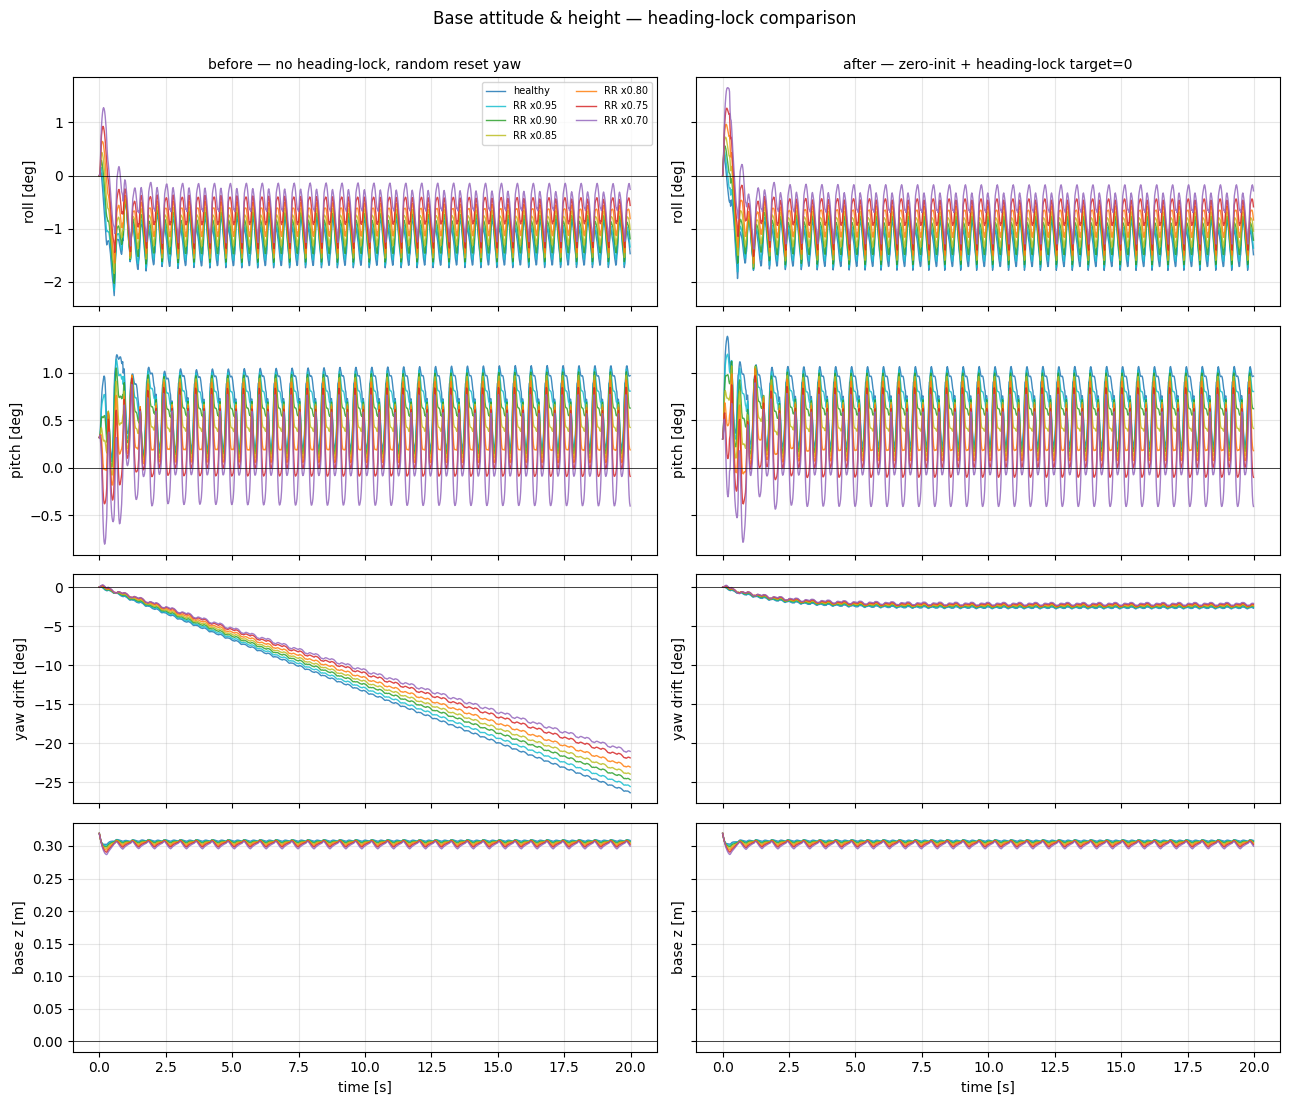

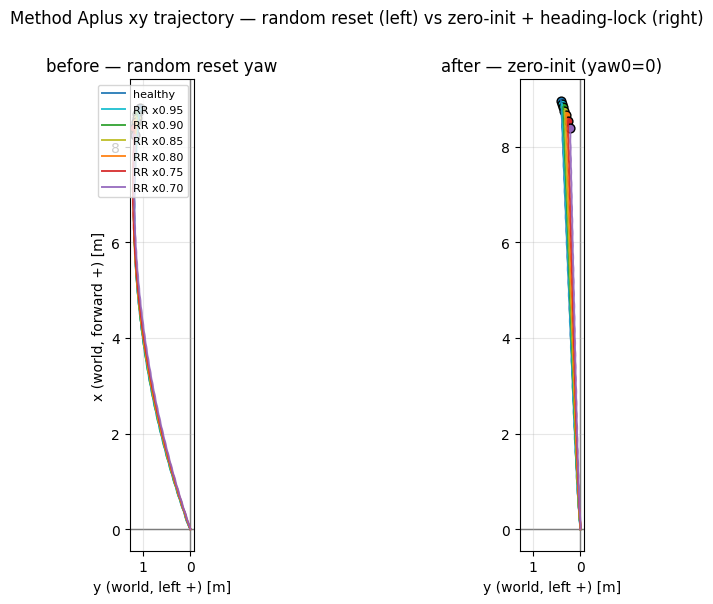


[heading-lock comparison] full-rollout metrics (T_MAX_S = 30.0s)
case        y_final before   y_final after    max|yawDrift| before    max|yawDrift| after
------------------------------------------------------------------------------------------
healthy           +1.058 m        +0.405 m              26.315 deg              2.788 deg
RR x0.95          +1.084 m        +0.385 m              25.514 deg              2.707 deg
RR x0.90          +1.111 m        +0.361 m              24.648 deg              2.630 deg
RR x0.85          +1.126 m        +0.332 m              23.925 deg              2.565 deg
RR x0.80          +1.145 m        +0.298 m              23.024 deg              2.501 deg
RR x0.75          +1.173 m        +0.262 m              21.891 deg              2.414 deg
RR x0.70          +1.159 m        +0.218 m              21.118 deg              2.357 deg


In [30]:
# ═══════════════════════════════════════════════════════════════════════
#  Heading-lock 비교 — cell-6 패턴 (base attitude / height / xy trajectory)
#  - left  : results/heading_lock_compare/aplus_tloop_hl_off/   (HL off, ki0 sweep 원본)
#  - right : results/heading_lock_compare/aplus_tloop_hl_on/    (zero-init + heading-lock target=0)
#  - 동일 7 case (healthy + RR 0.95~0.70), 동일 색.
# ═══════════════════════════════════════════════════════════════════════
TRANSIENT_S = 1.0

SWEEP_OLD = "./aplus_tloop_hl_off/data/aplus_tloop_ki000"                                  # before
SWEEP_HL  = "./aplus_tloop_hl_on/data/aplus_tloop_ki000"        # after

CASES_HL = [
    ("healthy",  "healthy.npz",  "tab:blue"),
    ("RR x0.95", "RR_0.95.npz",  "tab:cyan"),
    ("RR x0.90", "RR_0.90.npz",  "tab:green"),
    ("RR x0.85", "RR_0.85.npz",  "tab:olive"),
    ("RR x0.80", "RR_0.80.npz",  "tab:orange"),
    ("RR x0.75", "RR_0.75.npz",  "tab:red"),
    ("RR x0.70", "RR_0.70.npz",  "tab:purple"),
]

# ── (4 rows × 2 cols) 시계열 비교 — roll / pitch / yaw drift / z ─────
fig, axes = plt.subplots(4, 2, figsize=(13, 11), sharex=True, sharey='row')
sweeps = [(SWEEP_OLD, "before — no heading-lock, random reset yaw"),
          (SWEEP_HL,  "after — zero-init + heading-lock target=0")]
for col_idx, (sweep_dir, sweep_title) in enumerate(sweeps):
    for label, fname, color in CASES_HL:
        path = f"{sweep_dir}/{fname}"
        try:
            d = np.load(path, allow_pickle=True)
        except FileNotFoundError:
            continue
        m = json.loads(str(d["meta"]))
        t = np.arange(m["num_steps"]) * m["dt"]
        rpy_deg = np.rad2deg(d["base_rpy"])
        # yaw drift = unwrap(yaw) - yaw[0]  (각 case 자기 시작점 기준)
        yaw_drift = np.degrees(np.unwrap(d["base_rpy"][:, 2]) - d["base_rpy"][0, 2])
        z = d["base_pos"][:, 2]
        axes[0, col_idx].plot(t, rpy_deg[:, 0], color=color, lw=1.0, alpha=0.85, label=label)
        axes[1, col_idx].plot(t, rpy_deg[:, 1], color=color, lw=1.0, alpha=0.85, label=label)
        axes[2, col_idx].plot(t, yaw_drift,      color=color, lw=1.0, alpha=0.85, label=label)
        axes[3, col_idx].plot(t, z,              color=color, lw=1.0, alpha=0.85, label=label)
    axes[0, col_idx].set_title(sweep_title, fontsize=10)

for c in (0, 1):
    axes[0, c].set_ylabel("roll [deg]")
    axes[1, c].set_ylabel("pitch [deg]")
    axes[2, c].set_ylabel("yaw drift [deg]")
    axes[3, c].set_ylabel("base z [m]")
    axes[3, c].set_xlabel("time [s]")
    for r in range(4):
        axes[r, c].grid(alpha=0.3)
        axes[r, c].axhline(0, color="k", lw=0.5)
axes[0, 0].legend(loc="upper right", fontsize=7, ncol=2)
fig.suptitle("Base attitude & height — heading-lock comparison", y=1.0)
fig.tight_layout()
plt.show()

# ── xy trajectory 좌우 비교 ─────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 6))  # sharey 는 수동으로 통일
# 두 sweep 의 전체 (x, y) 데이터 범위 union 으로 axis limit 계산.
_all_x, _all_y = [], []
for _sweep_dir in (SWEEP_OLD, SWEEP_HL):
    for _label, _fname, _ in CASES_HL:
        try:
            _d = np.load(f"{_sweep_dir}/{_fname}", allow_pickle=True)
        except FileNotFoundError:
            continue
        _all_x.append(_d["base_pos"][:, 0] - _d["base_pos"][0, 0])
        _all_y.append(_d["base_pos"][:, 1] - _d["base_pos"][0, 1])
_all_x = np.concatenate(_all_x); _all_y = np.concatenate(_all_y)
_xmin, _xmax = float(_all_x.min()), float(_all_x.max())
_ymin, _ymax = float(_all_y.min()), float(_all_y.max())
_pad_x = 0.05 * max(_xmax - _xmin, 1e-3)
_pad_y = 0.05 * max(_ymax - _ymin, 1e-3)
for col_idx, (sweep_dir, sweep_title) in enumerate([
    (SWEEP_OLD, "before — random reset yaw"),
    (SWEEP_HL,  "after — zero-init (yaw0=0)"),
]):
    ax = axes2[col_idx]
    for label, fname, color in CASES_HL:
        path = f"{sweep_dir}/{fname}"
        try:
            d = np.load(path, allow_pickle=True)
        except FileNotFoundError:
            continue
        x = d["base_pos"][:, 0] - d["base_pos"][0, 0]   # forward
        y = d["base_pos"][:, 1] - d["base_pos"][0, 1]   # left
        ax.plot(y, x, color=color, lw=1.4, alpha=0.9, label=label)
        ax.scatter(y[-1], x[-1], color=color, s=40, marker="o", edgecolor="k")
    ax.axhline(0, color="k", lw=1.0, alpha=0.6, zorder=0)
    ax.axvline(0, color="k", lw=1.0, alpha=0.6, zorder=0)
    ax.set_xlabel("y (world, left +) [m]")
    # invert_xaxis 후 set_xlim 호출하면 invert 풀리므로 set_xlim 의 인자 순서로
    # 좌우 반전 (left=high, right=low) 을 직접 지정.
    ax.set_xlim(_ymax + _pad_y, _ymin - _pad_y)
    ax.set_ylim(_xmin - _pad_x, _xmax + _pad_x)
    ax.set_aspect("equal")
    ax.set_title(sweep_title)
    ax.grid(alpha=0.3)
axes2[0].set_ylabel("x (world, forward +) [m]")
axes2[0].legend(loc="upper right", fontsize=8)
fig2.suptitle("Method Aplus xy trajectory — random reset (left) vs zero-init + heading-lock (right)",
              y=1.0)
fig2.tight_layout()
plt.show()

# ── 정량 표 — y_final, max|yaw drift| 비교 ──────────────────────────
print(f"\n[heading-lock comparison] full-rollout metrics (T_MAX_S = {T_MAX_S}s)")
print(f"{'case':<10} {'y_final before':>15} {'y_final after':>15}  "
      f"{'max|yawDrift| before':>22} {'max|yawDrift| after':>22}")
print("-" * 90)
for label, fname, _ in CASES_HL:
    rec = {}
    for tag, sweep_dir in [("before", SWEEP_OLD), ("after", SWEEP_HL)]:
        try:
            d = np.load(f"{sweep_dir}/{fname}", allow_pickle=True)
        except FileNotFoundError:
            rec[tag] = None; continue
        yaw_unw = np.unwrap(d["base_rpy"][:, 2])
        y_final = float(d["base_pos"][-1, 1] - d["base_pos"][0, 1])
        max_drift_deg = float(np.degrees(np.max(np.abs(yaw_unw - yaw_unw[0]))))
        rec[tag] = (y_final, max_drift_deg)
    b, a = rec.get("before"), rec.get("after")
    bs = f"{b[0]:+7.3f} m" if b else "       -"
    as_= f"{a[0]:+7.3f} m" if a else "       -"
    bd = f"{b[1]:7.3f} deg" if b else "       -"
    ad = f"{a[1]:7.3f} deg" if a else "       -"
    print(f"{label:<10} {bs:>15} {as_:>15}  {bd:>22} {ad:>22}")


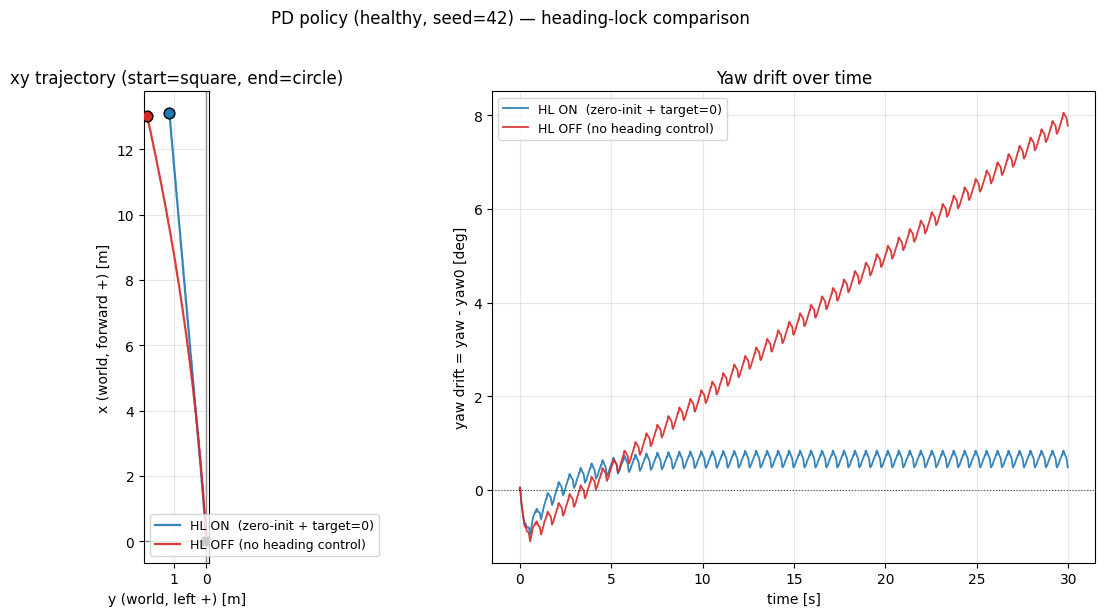


[PD policy, healthy]
case                                  yaw0[deg]  max|drift|[deg]   y_final[m]   x_final[m]
------------------------------------------------------------------------------------------
HL ON  (zero-init + target=0)            -0.022            0.951       +1.131      +13.116
HL OFF (no heading control)              -0.022            8.053       +1.815      +13.025


In [31]:
# ═══════════════════════════════════════════════════════════════════════
#  PD policy heading-lock 비교 — healthy only, seed=42, zero-init 적용
#  - HL ON  : --target-heading 0.0      (heading-lock 활성)
#  - HL OFF : --no-heading-control      (구 동작 — wz=0 manual, free yaw)
#  - 학습 시 PD policy 도 25 % heading-controlled 환경에서 학습되어 있음.
#  - 추론에서 heading-lock 켜고 끄는 차이를 healthy 직진성으로 확인.
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

CASES_PD = [
    ("HL ON  (zero-init + target=0)",
     "./pd_hl_on/data/pd/nominal.npz",  "tab:blue"),
    ("HL OFF (no heading control)",
     "./pd_hl_off/data/pd/nominal.npz", "tab:red"),
]

datas = []
for label, path, color in CASES_PD:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    datas.append(dict(label=label, color=color,
                      pos=d["base_pos"], rpy=d["base_rpy"],
                      t=np.arange(m["num_steps"]) * m["dt"],
                      mode=m.get("heading_mode"),
                      tgt=m.get("target_heading")))

fig, (ax_xy, ax_yaw) = plt.subplots(
    1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1.0, 1.2]})

# xy trajectory (robot-view: forward ↑, left ←)
for s in datas:
    x = s["pos"][:, 0] - s["pos"][0, 0]
    y = s["pos"][:, 1] - s["pos"][0, 1]
    ax_xy.plot(y, x, color=s["color"], lw=1.6, alpha=0.9, label=s["label"])
    ax_xy.scatter(y[-1], x[-1], color=s["color"], s=60, marker="o",
                  edgecolor="k", zorder=3)
    ax_xy.scatter(0, 0, color="k", s=30, marker="s", zorder=3)
ax_xy.axhline(0, color="k", lw=1.0, alpha=0.5, zorder=0)
ax_xy.axvline(0, color="k", lw=1.0, alpha=0.5, zorder=0)
ax_xy.set_xlabel("y (world, left +) [m]")
ax_xy.set_ylabel("x (world, forward +) [m]")
ax_xy.invert_xaxis()
ax_xy.set_aspect("equal")
ax_xy.set_title("xy trajectory (start=square, end=circle)")
ax_xy.grid(alpha=0.3)
ax_xy.legend(loc="lower left", fontsize=9)

# yaw drift 시계열
for s in datas:
    yaw_drift = np.degrees(np.unwrap(s["rpy"][:, 2]) - s["rpy"][0, 2])
    ax_yaw.plot(s["t"], yaw_drift, color=s["color"], lw=1.3, alpha=0.9,
                label=s["label"])
ax_yaw.axhline(0, color="k", lw=0.8, alpha=0.7, ls=":")
ax_yaw.set_xlabel("time [s]")
ax_yaw.set_ylabel("yaw drift = yaw - yaw0 [deg]")
ax_yaw.set_title("Yaw drift over time")
ax_yaw.grid(alpha=0.3)
ax_yaw.legend(loc="upper left", fontsize=9)

fig.suptitle("PD policy (healthy, seed=42) — heading-lock comparison",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

# 정량 요약
print(f"\n[PD policy, healthy]")
print(f"{'case':<36} {'yaw0[deg]':>10} {'max|drift|[deg]':>16} "
      f"{'y_final[m]':>12} {'x_final[m]':>12}")
print('-' * 90)
for s in datas:
    yaw = np.unwrap(s["rpy"][:, 2])
    yaw0 = float(np.degrees(yaw[0]))
    drift = np.degrees(yaw - yaw[0])
    yf = float(s["pos"][-1, 1] - s["pos"][0, 1])
    xf = float(s["pos"][-1, 0] - s["pos"][0, 0])
    print(f"{s['label']:<36} {yaw0:+10.3f} {float(np.abs(drift).max()):16.3f} "
          f"{yf:+12.3f} {xf:+12.3f}")


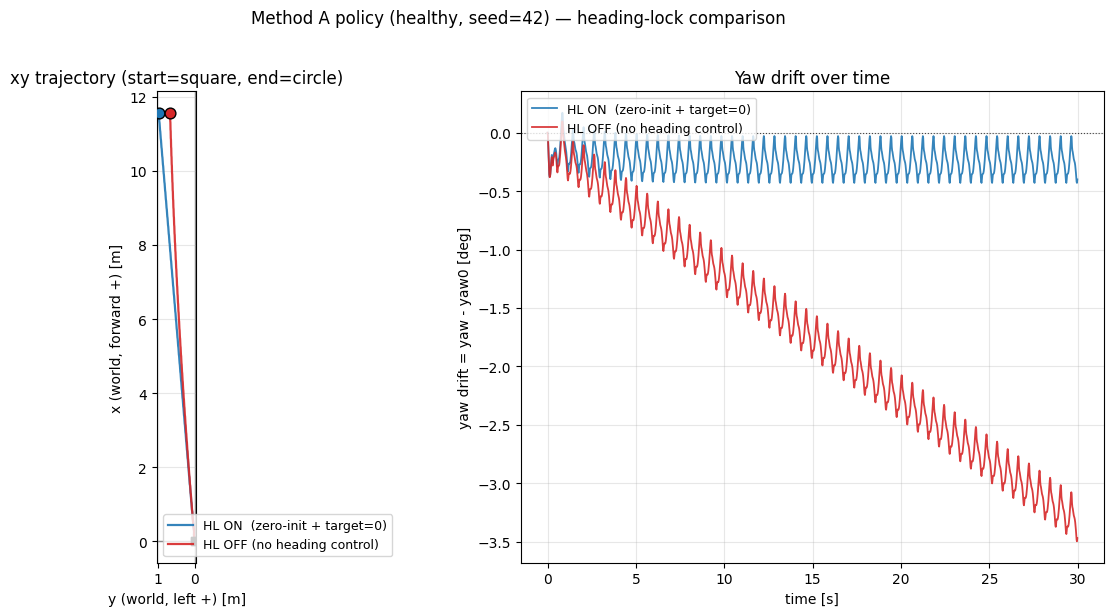


[Method A policy, healthy]
case                                  yaw0[deg]  max|drift|[deg]   y_final[m]   x_final[m]
------------------------------------------------------------------------------------------
HL ON  (zero-init + target=0)            +0.001            0.430       +0.972      +11.554
HL OFF (no heading control)              +0.001            3.497       +0.665      +11.569


In [32]:
# ═══════════════════════════════════════════════════════════════════════
#  Method A policy heading-lock 비교 — healthy only, seed=42, zero-init 적용
#  - HL ON  : --target-heading 0.0        (heading-lock 활성)
#  - HL OFF : --no-heading-control        (구 동작 — wz=0 manual, free yaw)
#  - Method A 는 전기모터 ODE 가 있지만 tloop 구현은 없음.
#  - 기존 aplus_tloop + Ki=0 sweep 과 같은 양상이 나와야 한다.
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

CASES_MA = [
    ("HL ON  (zero-init + target=0)",
     "./methoda_hl_on/data/methoda/healthy.npz",  "tab:blue"),
    ("HL OFF (no heading control)",
     "./methoda_hl_off/data/methoda/healthy.npz", "tab:red"),
]

datas = []
for label, path, color in CASES_MA:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    datas.append(dict(label=label, color=color,
                      pos=d["base_pos"], rpy=d["base_rpy"],
                      t=np.arange(m["num_steps"]) * m["dt"],
                      mode=m.get("heading_mode"),
                      tgt=m.get("target_heading")))

fig, (ax_xy, ax_yaw) = plt.subplots(
    1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1.0, 1.2]})

# xy trajectory (robot-view: forward ↑, left ←)
# 두 axes 의 데이터 union 으로 limit 통일.
_all_x = np.concatenate([s["pos"][:, 0] - s["pos"][0, 0] for s in datas])
_all_y = np.concatenate([s["pos"][:, 1] - s["pos"][0, 1] for s in datas])
_xmin, _xmax = float(_all_x.min()), float(_all_x.max())
_ymin, _ymax = float(_all_y.min()), float(_all_y.max())
_pad_x = 0.05 * max(_xmax - _xmin, 1e-3)
_pad_y = 0.05 * max(_ymax - _ymin, 1e-3)

for s in datas:
    x = s["pos"][:, 0] - s["pos"][0, 0]
    y = s["pos"][:, 1] - s["pos"][0, 1]
    ax_xy.plot(y, x, color=s["color"], lw=1.6, alpha=0.9, label=s["label"])
    ax_xy.scatter(y[-1], x[-1], color=s["color"], s=60, marker="o",
                  edgecolor="k", zorder=3)
    ax_xy.scatter(0, 0, color="k", s=30, marker="s", zorder=3)
ax_xy.axhline(0, color="k", lw=1.0, alpha=0.5, zorder=0)
ax_xy.axvline(0, color="k", lw=1.0, alpha=0.5, zorder=0)
ax_xy.set_xlabel("y (world, left +) [m]")
ax_xy.set_ylabel("x (world, forward +) [m]")
ax_xy.set_xlim(_ymax + _pad_y, _ymin - _pad_y)   # invert: left=high y
ax_xy.set_ylim(_xmin - _pad_x, _xmax + _pad_x)
ax_xy.set_aspect("equal")
ax_xy.set_title("xy trajectory (start=square, end=circle)")
ax_xy.grid(alpha=0.3)
ax_xy.legend(loc="lower left", fontsize=9)

# yaw drift 시계열
for s in datas:
    yaw_drift = np.degrees(np.unwrap(s["rpy"][:, 2]) - s["rpy"][0, 2])
    ax_yaw.plot(s["t"], yaw_drift, color=s["color"], lw=1.3, alpha=0.9,
                label=s["label"])
ax_yaw.axhline(0, color="k", lw=0.8, alpha=0.7, ls=":")
ax_yaw.set_xlabel("time [s]")
ax_yaw.set_ylabel("yaw drift = yaw - yaw0 [deg]")
ax_yaw.set_title("Yaw drift over time")
ax_yaw.grid(alpha=0.3)
ax_yaw.legend(loc="upper left", fontsize=9)

fig.suptitle("Method A policy (healthy, seed=42) — heading-lock comparison",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

# 정량 요약
print(f"\n[Method A policy, healthy]")
print(f"{'case':<36} {'yaw0[deg]':>10} {'max|drift|[deg]':>16} "
      f"{'y_final[m]':>12} {'x_final[m]':>12}")
print('-' * 90)
for s in datas:
    yaw = np.unwrap(s["rpy"][:, 2])
    yaw0 = float(np.degrees(yaw[0]))
    drift = np.degrees(yaw - yaw[0])
    yf = float(s["pos"][-1, 1] - s["pos"][0, 1])
    xf = float(s["pos"][-1, 0] - s["pos"][0, 0])
    print(f"{s['label']:<36} {yaw0:+10.3f} {float(np.abs(drift).max()):16.3f} "
          f"{yf:+12.3f} {xf:+12.3f}")
